In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/snehajuyal/SALES/SALES/output/cleaned_online_retail.csv")

In [3]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [4]:
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

In [5]:
df['CohortMonth'] = df.groupby('Customer ID')['InvoiceMonth'].transform('min')

In [6]:
invoice_year = df['InvoiceMonth'].dt.year
invoice_month = df['InvoiceMonth'].dt.month

cohort_year = df['CohortMonth'].dt.year
cohort_month = df['CohortMonth'].dt.month

In [7]:
df['CohortIndex'] = (
    (invoice_year - cohort_year) * 12
    + (invoice_month - cohort_month)
    + 1
)

In [8]:
cohort_data = df.groupby(
    ['CohortMonth', 'CohortIndex']
)['Customer ID'].nunique().reset_index()

In [9]:
cohort_data.head()

,CohortMonth,CohortIndex,Customer ID
0,2009-12,1,1045
1,2009-12,2,392
2,2009-12,3,358
3,2009-12,4,447
4,2009-12,5,410


In [10]:
cohort_table = cohort_data.pivot(
    index='CohortMonth',
    columns='CohortIndex',
    values='Customer ID'
)

In [11]:
cohort_table

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1045.0,392.0,358.0,447.0,410.0,408.0,408.0,374.0,355.0,392.0,...,319.0,273.0,316.0,303.0,287.0,274.0,332.0,319.0,427.0,218.0
2010-01,394.0,86.0,119.0,120.0,110.0,115.0,105.0,91.0,114.0,134.0,...,60.0,86.0,74.0,69.0,73.0,93.0,73.0,88.0,29.0,NaN
2010-02,363.0,109.0,82.0,110.0,93.0,76.0,79.0,103.0,100.0,106.0,...,74.0,67.0,61.0,53.0,85.0,90.0,62.0,23.0,NaN,NaN
2010-03,436.0,95.0,113.0,103.0,100.0,87.0,105.0,130.0,126.0,50.0,...,74.0,76.0,69.0,74.0,89.0,93.0,33.0,NaN,NaN,NaN
2010-04,291.0,67.0,58.0,47.0,54.0,67.0,79.0,76.0,33.0,34.0,...,43.0,41.0,41.0,50.0,61.0,19.0,NaN,NaN,NaN,NaN
2010-05,254.0,49.0,45.0,49.0,48.0,66.0,56.0,33.0,17.0,22.0,...,33.0,36.0,42.0,40.0,12.0,NaN,NaN,NaN,NaN,NaN
2010-06,269.0,58.0,53.0,55.0,62.0,76.0,35.0,25.0,22.0,32.0,...,33.0,37.0,55.0,16.0,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,183.0,38.0,37.0,52.0,55.0,28.0,21.0,28.0,26.0,22.0,...,32.0,45.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,158.0,39.0,50.0,51.0,29.0,21.0,16.0,22.0,23.0,21.0,...,32.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
retention = cohort_table.divide(
    cohort_table.iloc[:,0],
    axis=0
)

In [13]:
retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,1.0,0.375120,0.342584,0.427751,0.392344,0.390431,0.390431,0.357895,0.339713,0.375120,...,0.305263,0.261244,0.302392,0.289952,0.274641,0.262201,0.317703,0.305263,0.408612,0.208612
2010-01,1.0,0.218274,0.302030,0.304569,0.279188,0.291878,0.266497,0.230964,0.289340,0.340102,...,0.152284,0.218274,0.187817,0.175127,0.185279,0.236041,0.185279,0.223350,0.073604,NaN
2010-02,1.0,0.300275,0.225895,0.303030,0.256198,0.209366,0.217631,0.283747,0.275482,0.292011,...,0.203857,0.184573,0.168044,0.146006,0.234160,0.247934,0.170799,0.063361,NaN,NaN
2010-03,1.0,0.217890,0.259174,0.236239,0.229358,0.199541,0.240826,0.298165,0.288991,0.114679,...,0.169725,0.174312,0.158257,0.169725,0.204128,0.213303,0.075688,NaN,NaN,NaN
2010-04,1.0,0.230241,0.199313,0.161512,0.185567,0.230241,0.271478,0.261168,0.113402,0.116838,...,0.147766,0.140893,0.140893,0.171821,0.209622,0.065292,NaN,NaN,NaN,NaN
2010-05,1.0,0.192913,0.177165,0.192913,0.188976,0.259843,0.220472,0.129921,0.066929,0.086614,...,0.129921,0.141732,0.165354,0.157480,0.047244,NaN,NaN,NaN,NaN,NaN
2010-06,1.0,0.215613,0.197026,0.204461,0.230483,0.282528,0.130112,0.092937,0.081784,0.118959,...,0.122677,0.137546,0.204461,0.059480,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,1.0,0.207650,0.202186,0.284153,0.300546,0.153005,0.114754,0.153005,0.142077,0.120219,...,0.174863,0.245902,0.092896,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,1.0,0.246835,0.316456,0.322785,0.183544,0.132911,0.101266,0.139241,0.145570,0.132911,...,0.202532,0.069620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
retention = retention.round(3) * 100


In [15]:
retention

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,16,17,18,19,20,21,22,23,24,25
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2009-12,100.0,37.5,34.3,42.8,39.2,39.0,39.0,35.8,34.0,37.5,...,30.5,26.1,30.2,29.0,27.5,26.2,31.8,30.5,40.9,20.9
2010-01,100.0,21.8,30.2,30.5,27.9,29.2,26.6,23.1,28.9,34.0,...,15.2,21.8,18.8,17.5,18.5,23.6,18.5,22.3,7.4,NaN
2010-02,100.0,30.0,22.6,30.3,25.6,20.9,21.8,28.4,27.5,29.2,...,20.4,18.5,16.8,14.6,23.4,24.8,17.1,6.3,NaN,NaN
2010-03,100.0,21.8,25.9,23.6,22.9,20.0,24.1,29.8,28.9,11.5,...,17.0,17.4,15.8,17.0,20.4,21.3,7.6,NaN,NaN,NaN
2010-04,100.0,23.0,19.9,16.2,18.6,23.0,27.1,26.1,11.3,11.7,...,14.8,14.1,14.1,17.2,21.0,6.5,NaN,NaN,NaN,NaN
2010-05,100.0,19.3,17.7,19.3,18.9,26.0,22.0,13.0,6.7,8.7,...,13.0,14.2,16.5,15.7,4.7,NaN,NaN,NaN,NaN,NaN
2010-06,100.0,21.6,19.7,20.4,23.0,28.3,13.0,9.3,8.2,11.9,...,12.3,13.8,20.4,5.9,NaN,NaN,NaN,NaN,NaN,NaN
2010-07,100.0,20.8,20.2,28.4,30.1,15.3,11.5,15.3,14.2,12.0,...,17.5,24.6,9.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2010-08,100.0,24.7,31.6,32.3,18.4,13.3,10.1,13.9,14.6,13.3,...,20.3,7.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
import matplotlib.pyplot as plt

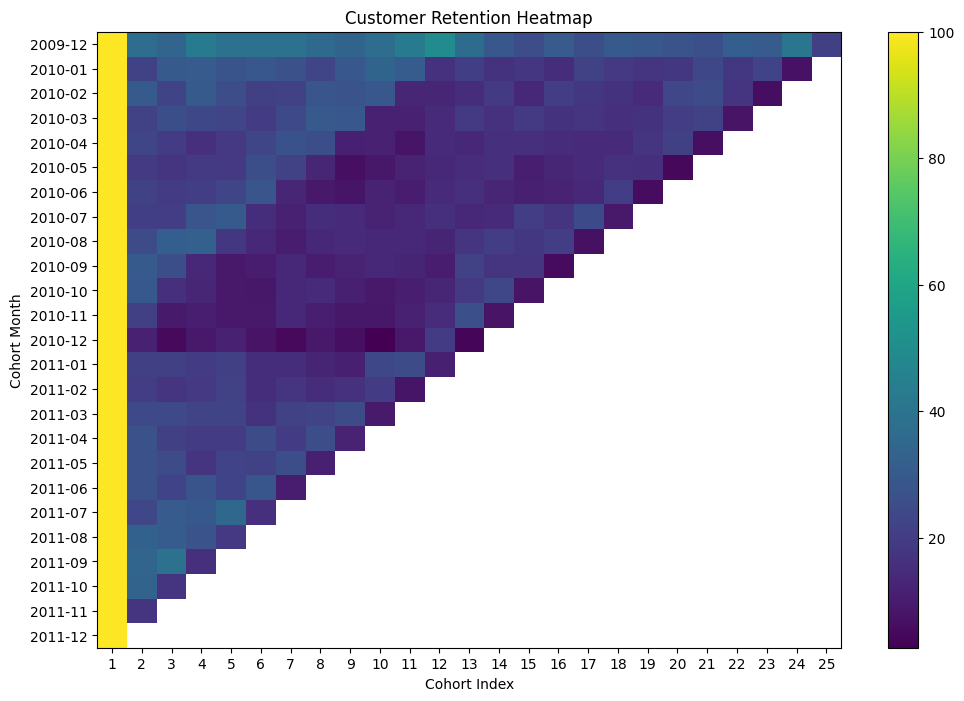

In [17]:
plt.figure(figsize=(12,8))

plt.imshow(retention, aspect='auto')

plt.colorbar()

plt.title("Customer Retention Heatmap")
plt.xlabel("Cohort Index")
plt.ylabel("Cohort Month")

plt.xticks(
    range(len(retention.columns)),
    retention.columns
)

plt.yticks(
    range(len(retention.index)),
    retention.index.astype(str)
)

plt.show()

In [18]:
retention.iloc[:,1].mean()

np.float64(25.025000000000006)

In [20]:
from pathlib import Path

out_path = Path("../output/cohort_retention.csv")
out_path.parent.mkdir(parents=True, exist_ok=True)

retention.to_csv(out_path)
print(f"Saved: {out_path}")


Saved: ../output/cohort_retention.csv


In [21]:
df.to_csv("/Users/snehajuyal/SALES/SALES/output/cohort_retention.csv", index=False)